In [1]:
# Customer Churn Prediction Using Logistic Regression 
## Business Problem 
# The goal of this project is to predict customer churn so that retention efforts can be targeted towards high risk customers 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
## Data Loading 

In [4]:
df = pd.read_csv("Telco Customer Churn Dataset.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
# Data Cleaning 

In [6]:
# ==================================================
# 1. Import Libraries
# ==================================================
# pandas is used for working with datasets.
# We use it to load the CSV file, view the data, clean columns,
# check missing vakues, and prepare the dataset for machine learning

import pandas as pd 

# ==================================================
# 2. Load the dataset
# ==================================================
# This reads the customer churn csv file into python 
# The dataset is store in a DataFrame named "df" 
# A DataFrame is like a table with rows and columns

df = pd.read_csv("Telco Customer Churn Dataset.csv")

# ==================================================
# 3. Preview the data
# ==================================================
# df.head() shows the first 5 rows of the dataset.
# This helps us quickly check whether the file loaded correctly
# and gives us a first look at the columns and values.

print(df.head())

# ============================================================
# 4. CHECK DATASET SIZE
# ============================================================
# df.shape shows the number of rows and columns.
# In this dataset, each row represents one customer.
# Each column represents information about that customer.

print(df.shape)

# ============================================================
# 5. CHECK DATA TYPES
# ============================================================
# df.info() shows each column, how many non-null values it has,
# and what data type Pandas assigned to it.
#
# This is important because machine learning models need numeric data.
# We also use this step to catch columns that were read incorrectly.
#
# In this dataset, TotalCharges appears as a string,
# but it should be numeric because it represents money charged.

print(df.info())


   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [7]:
#Exploratory Data Analysis 

In [8]:
# ============================================================
# 7. CONVERT TOTALCHARGES TO NUMERIC
# ============================================================
# TotalCharges should be a number, but Pandas read it as text.
# This usually happens when a column contains blank spaces or
# non-numeric values.
# pd.to_numeric() converts the column into numbers.
# errors="coerce" means:
# If a value cannot be converted into a number,
# turn it into NaN, which means missing value.

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"] , errors = "coerce")

# ============================================================
# 8. CHECK NEW MISSING VALUES
# ============================================================
# After converting TotalCharges, we check how many missing values
# were created.
#
# These missing values were probably hidden blank values before.

print(df["TotalCharges"].isnull().sum())

# ============================================================
# 9. DROP MISSING VALUES
# ============================================================
# Since the number of missing values is very small compared to
# the full dataset, we can remove those rows.
#
# dropna() removes rows that contain missing values.

df = df.dropna()

print(df.shape)
print(df.info())

# ============================================================
# 10. CONVERT TARGET COLUMN
# ============================================================
# Churn is the target column.
# This is what we want the model to predict.
#
# Right now, Churn contains "Yes" and "No".
# Machine learning models need numbers, so we convert:
#
# Yes = 1
# No = 0
#
# 1 means the customer churned.
# 0 means the customer did not churn.


df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

# ============================================================
# 11. CONVERT TARGET COLUMN
# ============================================================
# Churn is the target column.
# This is what we want the model to predict.
#
# Right now, Churn contains "Yes" and "No".
# Machine learning models need numbers, so we convert:
#
# Yes = 1
# No = 0
#
# 1 means the customer churned.
# 0 means the customer did not churn.

print(df.shape)
print(df.info())


# ============================================================
# 12. CHECK TARGET BALANCE
# ============================================================
# value_counts() shows how many customers churned vs did not churn.
#
# This is important because if one class is much larger than the other,
# accuracy alone may not be the best evaluation metric.
#
# For churn prediction, recall is especially important because
# we care about catching customers who are likely to leave.

print(df["Churn"].value_counts())

# Save the churn distribution as percentages, to make it easier for presentation

print(df["Churn"].value_counts(normalize=True))


# ======================================================
# EDA FINDINGS
# ======================================================
# Dataset contains 7,043 customer records and 21 variables.
# No obvious missing values were detected initially.
# TotalCharges was incorrectly stored as a string instead of a numeric value.
# After converting TotalCharges to numeric format, 11 hidden missing values were identified.
# These 11 records were removed, resulting in a final dataset of 7,032 customers.
# The Churn target variable was converted from Yes/No to 1/0.
# Final class distribution:
# Stayed: 5,163 customers (73.4%)
# Churned: 1,869 customers (26.6%)
# The dataset is moderately imbalanced but still suitable for classification modeling.

print(df.describe())

# ======================================================
# NUMERICAL FEATURE INSIGHTS
# ======================================================

# Average customer tenure: ~32 months
# Average monthly charge: ~$65
# Average lifetime customer value: ~$2,283
# Customer churn rate: ~26.6%
# About 1 in 4 customers leave the company.

# ============================================================
# EXAMINING THE CONTRACT COLUMN
# ============================================================
# value_counts() counts how many customers belong to each
# contract type.
# normalize=True converts the counts into proportions
# (percentages represented as decimals).
# This allows us to understand the distribution of customers
# across contract plans.
# Instead of:
# Month-to-month = 3875
# One year = 1473
# Two year = 1684
# We get:
# Month-to-month = 55%
# One year = 21%
# Two year = 24%
# Why this matters:
# Understanding the distribution of a feature helps identify
# whether one category dominates the dataset.
# It also helps us generate business insights.
# Example insight:
# "More than half of customers are on month-to-month contracts."
# This may become important later if month-to-month customers
# are more likely to churn.
# normalize=True is especially useful for presentations because
# percentages are easier to interpret than raw counts.

print(df["Contract"].value_counts(normalize=True))

# ============================================================
# ANALYZING THE RELATIONSHIP BETWEEN CONTRACT AND CHURN
# ============================================================
# pd.crosstab() creates a contingency table.
# It compares two categorical variables and shows how often
# each combination occurs.
# Here we are comparing:
# Feature:
# Contract
# Target:
# Churn
# The table will look something like:
#                  Churn
# Contract          0      1
# Month-to-month   XXXX   XXXX
# One year         XXXX   XXXX
# Two year         XXXX   XXXX
# Where:
# 0 = Customer stayed
# 1 = Customer churned
# This allows us to investigate whether contract type
# appears to influence customer churn.
# Why this matters:
# During EDA we are trying to answer:
# "Which features seem related to the target?"
# Crosstabs are one of the easiest ways to explore
# relationships between categorical variables and
# classification targets.
# Example insight:
# If month-to-month customers have significantly more churn
# than one-year or two-year customers, Contract may become
# an important predictor in the machine learning model.
# This is our first step toward identifying features that
# may help explain customer behavior.

print(pd.crosstab(df["Contract"], df["Churn"]))

# More than half of all customers are on month to month contracts

# Calculate churn rate by contract 
# Churn_rate = churned / total_customers_in_group
# Contract      Churn Rate
# Month to month - 42%
# One year       - 11%
# Two year.      - 2.8%
# Business interpretation: 
# Customers on month-to-month contracts are dramatically more likely to 
# churn than customers on longer-term contracts.
# Contract type appears to be a strong predictor of churn
# and will most likely be an important feature in the machine learning (ML) 
# model

# ======================================================
# FEATURE ENGINEERING - Creating better features, Convert Features into usable formats 
# Removing harmful or useless features 
# "Preparing information so the model can learn as effectively as possible"
# ======================================================
# customerID is unique for every customer and does not
# help predict churn, so we remove it.

df = df.drop("customerID", axis=1)

# Convert categorical variables into numeric features
# using one-hot encoding.
df_viz = df.copy()
df = pd.get_dummies(df, drop_first=True)

print(df.shape)
print(df.head())

11
(7032, 21)
<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   str    
 1   gender            7032 non-null   str    
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   str    
 4   Dependents        7032 non-null   str    
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   str    
 7   MultipleLines     7032 non-null   str    
 8   InternetService   7032 non-null   str    
 9   OnlineSecurity    7032 non-null   str    
 10  OnlineBackup      7032 non-null   str    
 11  DeviceProtection  7032 non-null   str    
 12  TechSupport       7032 non-null   str    
 13  StreamingTV       7032 non-null   str    
 14  StreamingMovies   7032 non-null   str    
 15  Contract          7032 non-null   str    
 16  PaperlessBilling  7032 non-null   str    
 1

In [9]:
## Model Development

In [10]:
# ====================================================
# TRAIN/TEST SPLIT - this is to split the data into test data and training data. 
# Typically your test data will be larger than your training data 
# ====================================================
from sklearn.model_selection import train_test_split

# Define X (features), y (target) 
X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split (
                                                    X, 
                                                    y, 
                                                     test_size=0.2, 
                                                     random_state=42, 
                                                     stratify=y
                                                     )

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

# ====================================================
# MODEL SECTION
# ====================================================

# Scale the data because the numeric features are on very different scales 
# tenure: 1 - 72
# MonthlyCharges: 18 - 119
# TotalCharges: 18 - 8685
# Scaling is not required to run Logistic Regression,
# but it is strongly recommended because it helps the
# model converge and often improves performance.
# StandardScaler standardizes features so they have
# Mean = 0 
# Standard Deviation = 1 
# This helps Logistic Regression converge faster and often
# improves model performance.
# fit_transform() is used on X_train because the scaler learns
# the scaling parameters from the training data.
# transform() is used on X_test so the test data is scaled
# using the exact same parameters.
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# Import the LogisticRegression Model ( this project uses logistic regression because we are
# predicting categories not numberical values which would be LinearRegression)
from sklearn.linear_model import LogisticRegression

# Create the logistic regression model
# max_iter controls the max number of training iterations 
# the model is allowed to perform
# larger datasets or datasets with many features may need 
# more iterations before the model converges
# so max_iter=1000 gives the model enough opportunities to find 
# the best coefficients
churn_model = LogisticRegression(max_iter=1000)

# Train the model using the training data 
churn_model.fit(X_train, y_train)

# Use the trained model to predict churn on the test data 
y_pred = churn_model.predict(X_test)

# print the first 10 results using [:10] which is "slicing"
# starting from 0 to the 10th prediction. Thisis to confirm quickly
# that the model generated reasonable outputs
# 0 = customer stays 
# 1 = costumer churns
print(y_pred[:10])

(5625, 30)
(1407, 30)
(5625,)
(1407,)
[0 1 0 0 0 0 0 0 1 0]


In [11]:
# Model Evaluation

In [12]:
# ======================================================
# MODEL EVALUATION
# ======================================================
# After training the Logistic Regression model and generating
# predictions, we need to evaluate how well the model performs.
# The goal is to determine how accurately the model can identify
# customers who are likely to churn.
# We use several evaluation metrics because no single metric
# tells the entire story.
# Accuracy:
# Measures the overall percentage of correct predictions.
# Precision:
# Measures how often the model is correct when it predicts
# that a customer will churn.
# Recall:
# Measures how many actual churners the model successfully
# identifies.
# Confusion Matrix:
# Shows the detailed breakdown of correct and incorrect
# predictions.
# For churn prediction, Recall is often one of the most
# important metrics because businesses want to identify
# customers who are likely to leave before they churn.

# ======================================================
# IMPORT EVALUATION METRICS
# ======================================================
# accuracy_score:
# Calculates the overall prediction accuracy.
# precision_score:
# Measures the reliability of positive churn predictions
# recall_score:
# Measures how many actual churners were identified.
# confusion_matrix:
# Provides a detailed table of prediction outcomes.
# roc_auc_score:
# Measures the model's ability to distinguish between
# churners and non-churners across different thresholds.
# ROC-AUC will be covered after understanding the basic
# evaluation metrics.

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    roc_auc_score
)

# ======================================================
# CALCULATE ACCURACY
# ======================================================
# Accuracy measures the percentage of predictions that
# were correct.
# Formula:
# Correct Predictions
# -------------------
# Total Predictions
# Example:
# Accuracy = 0.81
# Interpretation:
# The model correctly classified 81% of customers.
# Important:
# High accuracy does not always mean a good model.
# For imbalanced datasets, a model can achieve high
# accuracy while performing poorly on the minority class.
print("Accuracy:", accuracy_score(y_test, y_pred))

# ======================================================
# CALCULATE PRECISION
# ======================================================
# Precision answers the question:
# "When the model predicts churn, how often is it correct?"
# Formula:
# True Positives
# --------------------------------
# True Positives + False Positives
# Example:
# Precision = 0.68
# Interpretation:
# When the model predicts that a customer will churn,
# it is correct 68% of the time.
# Precision is important when false alarms are costly.
print("Precision:", precision_score(y_test, y_pred))

# ======================================================
# CALCULATE RECALL
# ======================================================
# Recall answers the question:
# "Of all customers who actually churned,
# how many did the model identify?"
# Formula:
# True Positives
# --------------------------------
# True Positives + False Negatives
# Example:
# Recall = 0.55
# Interpretation:
# The model successfully identified 55% of all customers
# who actually churned.
# Recall is often one of the most important metrics for
# churn prediction because missing churners can result in
# lost revenue and missed retention opportunities.

print("Recall:", recall_score(y_test, y_pred))

# ======================================================
# CONFUSION MATRIX
# ======================================================
# The confusion matrix provides a detailed breakdown of
# prediction results.
# Structure:
#                 Predicted
#                0        1
#
# Actual 0      TN       FP
#
# Actual 1      FN       TP
#
# Where:
# TN = True Negative
#      Correctly predicted customer stayed.
# FP = False Positive
#      Predicted churn but customer stayed.
# FN = False Negative
#      Predicted stay but customer churned.
# TP = True Positive
#      Correctly predicted customer churned.
# The confusion matrix helps explain exactly where the
# model is making mistakes.
# Accuracy, Precision, and Recall are all calculated
# from these four values.
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# ======================================================
# FINDINGS
# ======================================================
# The Logistic Regression model achieved an accuracy of 80.4%, indicating strong overall classification performance. 
# When predicting customer churn, the model was correct 64.8% of the time (precision) when the model predicted churn it was correct 64.8% of the time . 
# The model successfully identified 57.5% of customers who ultimately churned (recall), though it missed 159 churning customers.
# Of all customers who actually churned the model successfully identified 57.5% 
# Because customer retention is a business priority, future work should focus on improving recall, 
# even if it comes at a small cost to precision.

# Get probabilities 
# predict_proba (on test data X_test) returns the values (probability that stay , probability that will leave) 
# Since we only want the churn probability we use [:,1] which means all rows, column 1 ( churn probability)
y_pred_prob = churn_model.predict_proba(X_test)[:,1]

print(y_pred_prob[:10])

# ======================================================
# ROC-AUC SCORE
# ======================================================
# ROC-AUC measures the model's ability to distinguish
# between customers who churn and customers who stay.
# Unlike accuracy, ROC-AUC evaluates the model across
# many possible decision thresholds.
# Interpretation:
# 0.50 = Random guessing
# 0.60 = Poor
# 0.70 = Fair
# 0.80 = Good
# 0.90 = Excellent
# 1.00 = Perfect separation
# In churn prediction, ROC-AUC is often preferred because
# it measures how well the model ranks customers by churn
# risk rather than relying on a single classification
# threshold.
# predict_proba() returns probabilities for each class.
# [:,1] selects the probability that a customer belongs
# to class 1 (Churn).
roc_score = roc_auc_score(y_test, y_pred_prob)

print("ROC-AUC:", roc_score)

# The Logistic Regression model achieved an ROC-AUC score of 0.836, indicating good discriminatory performance.
# The model was able to distinguish between customers who churned and customers who remained with approximately 83.6% 
# effectiveness, suggesting that it provides useful predictive insight for customer retention efforts.

# ======================================================
# FEATURE IMPORTANCE ANALYSIS
# ======================================================
#
# Logistic Regression learns a coefficient for each feature.
#
# These coefficients help us understand how each feature
# influences the probability that a customer will churn.
#
# Positive coefficients:
# Increase the likelihood of churn.
#
# Negative coefficients:
# Decrease the likelihood of churn.
#
# Larger absolute values indicate stronger influence on
# the model's predictions.
#
# Feature importance helps answer:
#
# "Which factors are most associated with customer churn?"
#
# This is often one of the most valuable parts of a machine
# learning project because it provides actionable business
# insights rather than only predictive performance.

# ======================================================
# CREATE FEATURE IMPORTANCE TABLE
# ======================================================
#
# churn_model.coef_[0] contains the learned coefficients
# from the Logistic Regression model.
#
# We combine feature names and coefficients into a DataFrame
# so they can be sorted and interpreted more easily.
#
# Positive values indicate higher churn risk.
# Negative values indicate lower churn risk.

coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": churn_model.coef_[0]
})
# ======================================================
# SORT FEATURES BY IMPORTANCE
# ======================================================
#
# Sorting by coefficient allows us to identify:
#
# Features most strongly associated with churn
# Features most strongly associated with retention
#
# The largest positive coefficients represent the strongest
# churn drivers.
#
# The largest negative coefficients represent the strongest
# retention drivers.

coef_df = coef_df.sort_values(
    by="Coefficient",
    ascending=False
)



print(coef_df.head(10))

print(coef_df.tail(10))

# ======================================================
# TOP CHURN DRIVERS
# ======================================================
#
# These features increase churn probability.
#
# Key findings from this project:
#
# InternetService_Fiber optic (+0.728)
# Strongest churn-increasing feature.
#
# TotalCharges (+0.639)
# Higher lifetime charges are associated with increased
# churn risk.
#
# StreamingTV (+0.250)
# StreamingMovies (+0.236)
#
# Customers using streaming services appear slightly more
# likely to churn.
#
# Electronic Check Payments (+0.181)
#
# Customers paying by electronic check show elevated
# churn risk compared to customers using automatic
# payment methods.

# ======================================================
# TOP RETENTION DRIVERS
# ======================================================
#
# These features decrease churn probability.
#
# tenure (-1.348)
#
# Strongest retention feature in the model.
#
# Customers who remain with the company longer are
# significantly less likely to churn.
#
# Contract_Two year (-0.603)
# Contract_One year (-0.311)
#
# Long-term contracts are strongly associated with
# customer retention.
#
# OnlineSecurity_Yes (-0.137)
# TechSupport_Yes (-0.118)
#
# Customers using security and support services are
# more likely to remain customers.

# ======================================================
# IMPORTANT INTERPRETATION 
# ======================================================
#
# Feature importance identifies associations, not
# necessarily causes.
#
# Some features may be correlated with one another.
#
# For example:
#
# TotalCharges is related to:
# - MonthlyCharges
# - tenure
#
# Because of this, coefficients should be interpreted
# as indicators of influence within the model rather
# than proof of causation.
#
# Feature importance is best used to identify patterns,
# generate business insights, and guide future analysis.

Accuracy: 0.8038379530916845
Precision: 0.6475903614457831
Recall: 0.5748663101604278
Confusion Matrix:
[[916 117]
 [159 215]]
[0.01711495 0.59613179 0.00476432 0.20004408 0.10022205 0.4700293
 0.02661132 0.16414898 0.68614136 0.01518016]
ROC-AUC: 0.8356727976766699
                           Feature  Coefficient
10     InternetService_Fiber optic     0.727745
3                     TotalCharges     0.639028
21                 StreamingTV_Yes     0.249702
23             StreamingMovies_Yes     0.236368
9                MultipleLines_Yes     0.214359
28  PaymentMethod_Electronic check     0.181473
26            PaperlessBilling_Yes     0.142663
0                    SeniorCitizen     0.070792
17            DeviceProtection_Yes     0.068965
29      PaymentMethod_Mailed check     0.033392
                               Feature  Coefficient
11                  InternetService_No    -0.088138
14    OnlineBackup_No internet service    -0.088138
12  OnlineSecurity_No internet service    -0.0881

In [13]:
# Visualization No.1

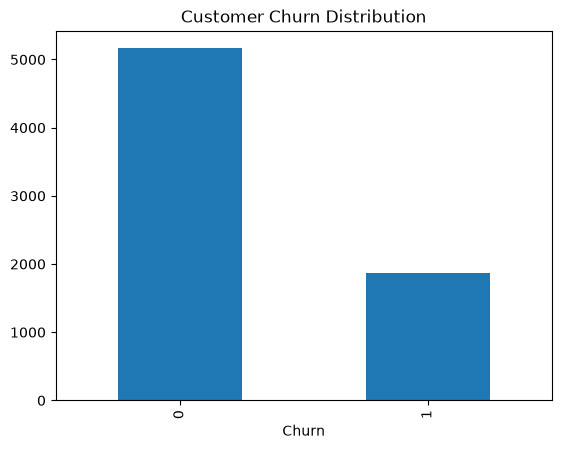

In [14]:
df["Churn"].value_counts().plot(kind="bar")
plt.title("Customer Churn Distribution")
plt.show()

In [16]:
pd.crosstab(
    df_viz["Contract"],
    df_viz["Churn"],
    normalize="index"
)

Churn,0,1
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887228,0.112772
Two year,0.971513,0.028487


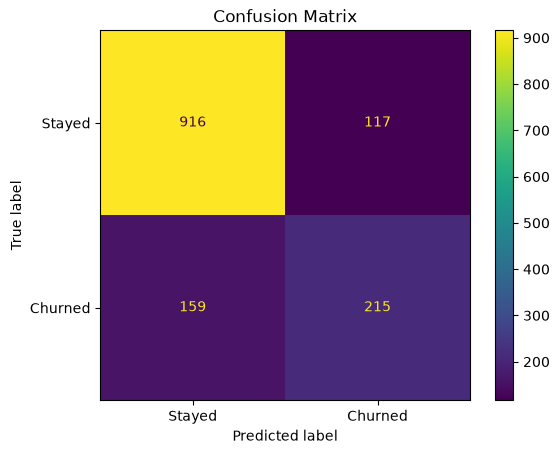

In [17]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Stayed", "Churned"]
)

plt.title("Confusion Matrix")
plt.show()

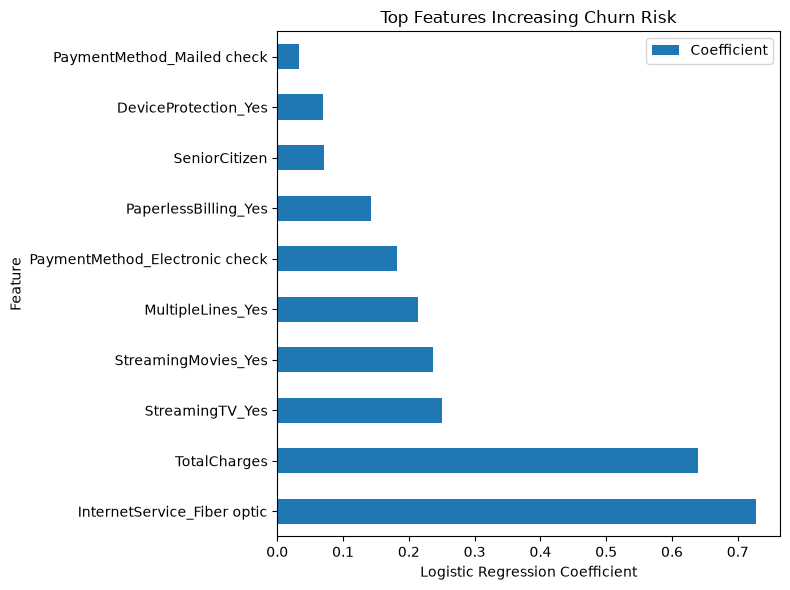

In [18]:
top_positive = coef_df.sort_values(
    by="Coefficient",
    ascending=False
).head(10)

top_positive.plot(
    x="Feature",
    y="Coefficient",
    kind="barh",
    figsize=(8,6)
)

plt.title("Top Features Increasing Churn Risk")
plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

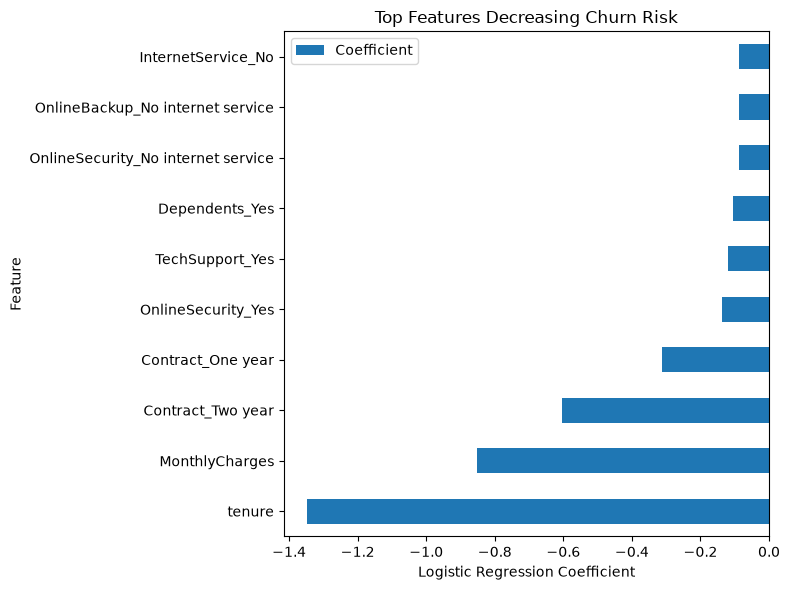

In [19]:
top_negative = coef_df.sort_values(
    by="Coefficient",
    ascending=True
).head(10)

top_negative.plot(
    x="Feature",
    y="Coefficient",
    kind="barh",
    figsize=(8,6)
)

plt.title("Top Features Decreasing Churn Risk")
plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

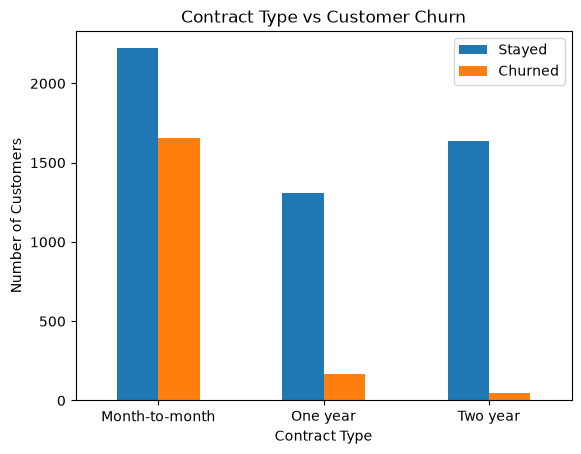

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

contract_churn = pd.DataFrame({
    "Stayed": [2220, 1306, 1637],
    "Churned": [1655, 166, 48]
},
index=["Month-to-month", "One year", "Two year"])

contract_churn.plot(kind="bar")

plt.title("Contract Type vs Customer Churn")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

plt.show()